# Main notebook for project P2

Outline
- Data loading
- Data processing/creation
- Data analysis 
- Demo of promt strategy 


## Dataloading

The MathArena dataset contains two types of tables: 
- probelm: Here details about the problem in the competition
- outputs: Here is information about all model attempts at solving the probelm

We have created an utility module math_arena_datasets to load the datasets from huggingface that will use. 
In this seciton we will 
- Load both datasets
- print out an example row of each dataset/table type
- print out all the colums of each dataset/table type. Notice, that not all competitions will have the same columns, which we will handle in the data preprocessing section

In [80]:
# To make the notebook reload everytime
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import pandas as pd
from math_arena_datasets import load_data_dict

problem_data_dict = load_data_dict(table_type="problem")
outputs_data_dict = load_data_dict(table_type="outputs")

We can now join all the columns for each table type acrros competitins and se an example of a row: 

In [82]:
from math_arena_datasets import get_all_cols_from_data_dict

print("Problem Cols:")
for x in get_all_cols_from_data_dict(problem_data_dict): print("  ", x)

Problem Cols:
   sample_grading
   __index_level_0__
   problem_type
   sample_solution
   source
   grading_scheme
   problem_idx
   points
   image
   competition
   problem
   answer


In [83]:
from math_arena_datasets import pick_competition_element
competition_name, competition_dataset = pick_competition_element(0, problem_data_dict)


print(competition_name)
competition_dataset["train"].to_pandas().head(1)

MathArena/apex_2025


,problem_idx,problem,answer,source,__index_level_0__
0,1,Let \( f: \mathbb{R} \to \mathbb{R} \) be a co...,4049,All Russian 2025 11.8,0


In [84]:
print("Output Cols:")
for x in get_all_cols_from_data_dict(outputs_data_dict): print("  ",x)

Output Cols:
   __index_level_0__
   parsed_answer
   model_config
   max_points_judge_1
   max_points_judge_2
   model_name
   correct
   error_judge_2
   output_cost_per_tokens
   grading_details_judge_2
   grading_details_judge_1
   error_judge_1
   points_judge_2
   input_cost_per_tokens
   idx_answer
   answer
   gold_answer
   input_tokens
   points_judge_1
   source
   output_tokens
   problem_idx
   image
   cost
   user_message
   problem


In [85]:
from math_arena_datasets import pick_competition_element
competition_name, competition_dataset = pick_competition_element(0, outputs_data_dict)


print(competition_name)
competition_dataset["train"].to_pandas().head(1)

MathArena/apex_2025_outputs


,problem_idx,problem,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,cost,input_cost_per_tokens,output_cost_per_tokens,source,gold_answer,parsed_answer,correct,__index_level_0__
0,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,22492,0.337827,3.0,15.0,IMO 2025 P6,2112,4048,False,0


## Data processing
In this section we will
- Adding a unique joint competion problem index
- Find and drop proof based answers / answers where the model should submit a proof
- Dropping image based answers (Kangaroo)
- Find and drop coulumns with high missing value ratio

### A unique problem label/index
Every competition starts ther problem index from 0 or 1. Thus it is not unique accros competitions. For easier selection, we therefore create a new index column called `unique_problem_label`, which we can use to uniquely identify both problems but also allow for easy joins between problem and outputs dataset.

To do this, we will use an utility module we have created called `data_processing_utils.py`. 
In here, the function `create_unique_problem_label_and_return_df` creates this label and for convenience, return the results as dataframe rather than a dict of hugging face `DataDict`


In [86]:
from data_processing_utils import create_unique_problem_label_and_return_df

df_problem = create_unique_problem_label_and_return_df(problem_data_dict)
df_outputs = create_unique_problem_label_and_return_df(outputs_data_dict)

Unfortunately, there is some inconsistencies in the naming in the MathArena dataset. For instance, sometimes the "-" is used in place od "_". Thus, we clean this in the following cell

In [87]:
from data_processing_utils import clean_column, UNIQUE_PROBLEM_LABEL

df_problem = clean_column(df_problem, UNIQUE_PROBLEM_LABEL)
df_outputs = clean_column(df_outputs, UNIQUE_PROBLEM_LABEL)

In [88]:
print("number of problems", len(df_problem))
df_problem.head(1)

number of problems 527


,problem_idx,problem,answer,source,__index_level_0__,unique_problem_label,competition,problem_type,points,grading_scheme,sample_solution,sample_grading,image
0,1,Let \( f: \mathbb{R} \to \mathbb{R} \) be a co...,4049,All Russian 2025 11.8,0.0,MathArena/apex_2025: 1,MathArena/apex_2025,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
print("Number of total model answers", len(df_outputs))
df_outputs.head(1)

Number of total model answers 31202


,problem_idx,problem,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,cost,...,competition,points_judge_1,grading_details_judge_1,error_judge_1,max_points_judge_1,points_judge_2,grading_details_judge_2,error_judge_2,max_points_judge_2,image
0,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,22492.0,0.337827,...,MathArena/apex_2025_outputs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dropping the proof based answers
While the proof based answers are the most promising in terms of judging a model reasoning capabilities, it is also the most expensive to check, since you need an expert in the field of the question. We do not have those resources in this project, so for the scope of this project we choose to drop this part of the dataset. 

The proof based problems reveals themselves by having an entry in the `judge` columns. That is because you need a judge to veriy the proof. So, we can simply drop all rows in the output dataset that has as non `nan` entry in these columns. 


In [90]:
from data_processing_utils import drop_judge_column_rows
df_outputs= drop_judge_column_rows(df_outputs)
print("new length outputs", len(df_outputs))

new length outputs 30764


And now, the judge columns are unpopulated, so we can drop them. 

In [91]:
from data_processing_utils import drop_judge_columns
df_outputs = drop_judge_columns(df_outputs)

df_outputs.columns

here


Index(['problem_idx', 'problem', 'model_name', 'model_config', 'idx_answer',
       'user_message', 'answer', 'input_tokens', 'output_tokens', 'cost',
       'input_cost_per_tokens', 'output_cost_per_tokens', 'source',
       'gold_answer', 'parsed_answer', 'correct', '__index_level_0__',
       'unique_problem_label', 'competition', 'image'],
      dtype='object')

We also need to delete the same rows in the problem dataset


In [92]:
output_set = set(df_outputs[UNIQUE_PROBLEM_LABEL].unique())
problem_set = set(df_problem[UNIQUE_PROBLEM_LABEL].unique())

problems_to_keep = output_set.intersection(problem_set)
df_problem = df_problem[df_problem[UNIQUE_PROBLEM_LABEL].isin(problems_to_keep)]
len(df_problem)

337

### Dropping the image based questions

In [93]:
from data_processing_utils import remove_kangaroo_competitions
df_problem = remove_kangaroo_competitions(df_problem)
df_outputs = remove_kangaroo_competitions(df_outputs)

In [94]:
print("Number of problems", len(df_problem))
print("Number of outputs", len(df_outputs))

Number of problems 169
Number of outputs 25388


### Find cloumn columns with high missing value ratio


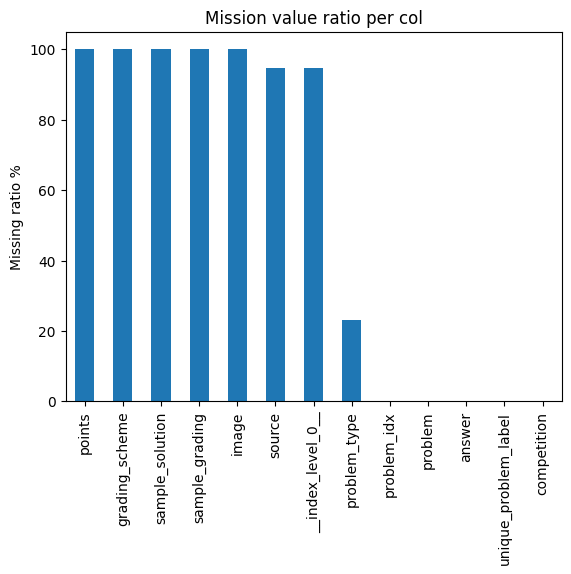

In [95]:
from data_processing_utils import find_missing_value_ratios, plot_missing
miss_problem = find_missing_value_ratios(df_problem)
miss_problem
plot_missing(miss_problem)

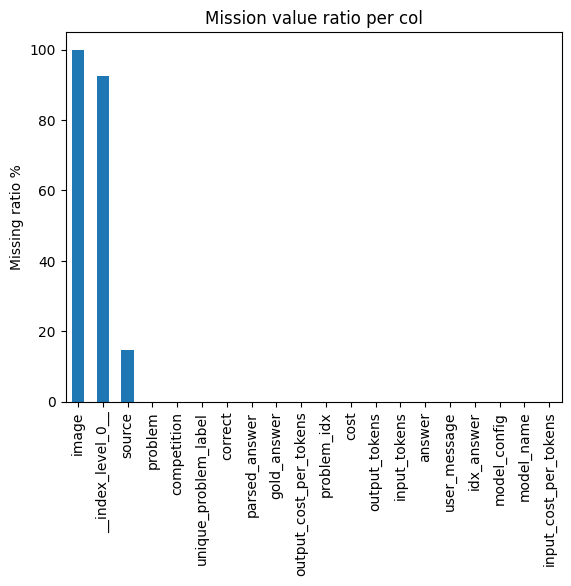

In [96]:
miss_outputs = find_missing_value_ratios(df_outputs)
miss_outputs
plot_missing(miss_outputs)

Now we will drop coloumn with missing value ration over 25%

In [97]:
from data_processing_utils import prune_missing
df_problem = prune_missing(df_problem, missing_ratio=miss_problem, threshold=0.25)
df_problem.columns

Index(['problem_type', 'problem_idx', 'problem', 'answer',
       'unique_problem_label', 'competition'],
      dtype='object')

In [98]:
df_outputs = prune_missing(df_outputs, missing_ratio=miss_outputs, threshold=0.25)
df_outputs.columns

Index(['source', 'problem', 'competition', 'unique_problem_label', 'correct',
       'parsed_answer', 'gold_answer', 'output_cost_per_tokens', 'problem_idx',
       'cost', 'output_tokens', 'input_tokens', 'answer', 'user_message',
       'idx_answer', 'model_config', 'model_name', 'input_cost_per_tokens'],
      dtype='object')

## Data analysis
In this section we will: 
- Give problems a difficulty score by arranging them in terms of 10% percentiles
- Propose two solutions to handle the problem of the 75 % missing values of the catagory label

### Difficulty score / grouping by 10% percentile
For this project, we wish to select a fitting subset of problems to test our promting hypothesis on. However, not all problmes are euqally difficult. One way to measure difficulty is to look at how many models got an problem right or the correct prediction to wrong prediction ratio. When doing this we can then group problems by ther 10 percent percentile. 



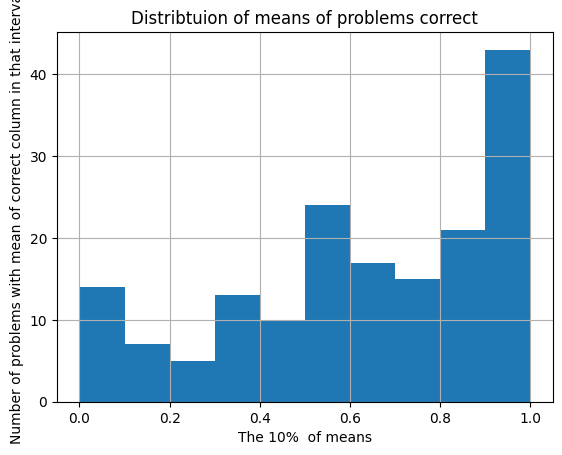

In [99]:
import matplotlib.pyplot as plt
bins = 10
CORRECT = "correct"
grouped = df_outputs.groupby(UNIQUE_PROBLEM_LABEL)[CORRECT].mean()

h = grouped.hist(bins=bins)
plt.xlabel(f"The {bins}%  of means")
plt.ylabel("Number of problems with mean of correct column in that interval")
plt.title("Distribtuion of means of problems correct")
plt.show()

In [102]:
from data_analysis import create_ten_percentile_group
df_outputs = create_ten_percentile_group(df_outputs)
df_outputs.head(5)[["unique_problem_label", "ten_percentile_group"]]

,unique_problem_label,ten_percentile_group
0,MathArena/apex_2025: 12,1
1,MathArena/apex_2025: 12,1
2,MathArena/apex_2025: 12,1
3,MathArena/apex_2025: 12,1
4,MathArena/apex_2025: 12,1


### Catagory label
While the difficucly feature is nice, it would be benifitial to have more in order to judge the models performance and to select a proper subset of problems. One promising feature is category. However, as we have already shown, only 25% of the dataset contains the label catategory. What is is worse is, that the problems are on such a high level of mathematics, that we cannot properly label the rest of the 75 % ourselves. 

We tried a few approacsh to generate theese labels, which we reference in the appendix. 


## Demo of promt strategy

For the demo, reference the notebook multi_agent_demo.ipynb (we know the project description only specified one main.ipynb, but we had already ran the texperiemnts in that notebook)